<a href="https://colab.research.google.com/github/ayeshabaig575/FYP/blob/main/U2_net_deepsk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import MeanIoU, Precision, Recall
from sklearn.model_selection import train_test_split
from glob import glob

In [15]:
# Dataset paths (adjust to your Google Drive path)
dataset_path = "/content/drive/MyDrive/Dataset_BUSI_with_GT"  # Change this
paths = glob(os.path.join(dataset_path, "*/*"))

In [16]:
# Verify dataset loading
print(f"Total files found: {len(paths)}")
print(f"'normal' class has {len([i for i in paths if 'normal' in i and 'mask' not in i])} images and {len([i for i in paths if 'normal' in i and 'mask' in i])} masks.")
print(f"'benign' class has {len([i for i in paths if 'benign' in i and 'mask' not in i])} images and {len([i for i in paths if 'benign' in i and 'mask' in i])} masks.")
print(f"'malignant' class has {len([i for i in paths if 'malignant' in i and 'mask' not in i])} images and {len([i for i in paths if 'malignant' in i and 'mask' in i])} masks.")
print(f"\nTotal images: {len([i for i in paths if 'mask' not in i])}, Total masks: {len([i for i in paths if 'mask' in i])}")

Total files found: 1578
'normal' class has 133 images and 133 masks.
'benign' class has 437 images and 454 masks.
'malignant' class has 210 images and 211 masks.

Total images: 780, Total masks: 798


In [17]:
# Data loading functions
def load_image(path, size):
    image = cv2.imread(path)
    image = cv2.resize(image, (size, size))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Keep RGB for U²-Net
    image = image/255.0
    return image

def load_data(root_path, size):
    images = []
    masks = []
    x = 0  # flag for multiple masks

    for path in sorted(glob(root_path)):
        img = load_image(path, size)

        if 'mask' in path:
            if x:  # if previous image had this mask
                masks[-1] += img[..., 0]  # use red channel only for masks
                masks[-1] = np.array(masks[-1] > 0.5, dtype='float32')
            else:
                masks.append(img[..., 0])  # use red channel only for masks
                x = 1
        else:
            images.append(img)
            x = 0

    return np.array(images), np.array(masks)


In [18]:
# Load data
size = 320  # U²-Net typically uses larger images
X, y = load_data(os.path.join(dataset_path, "*/*"), size)


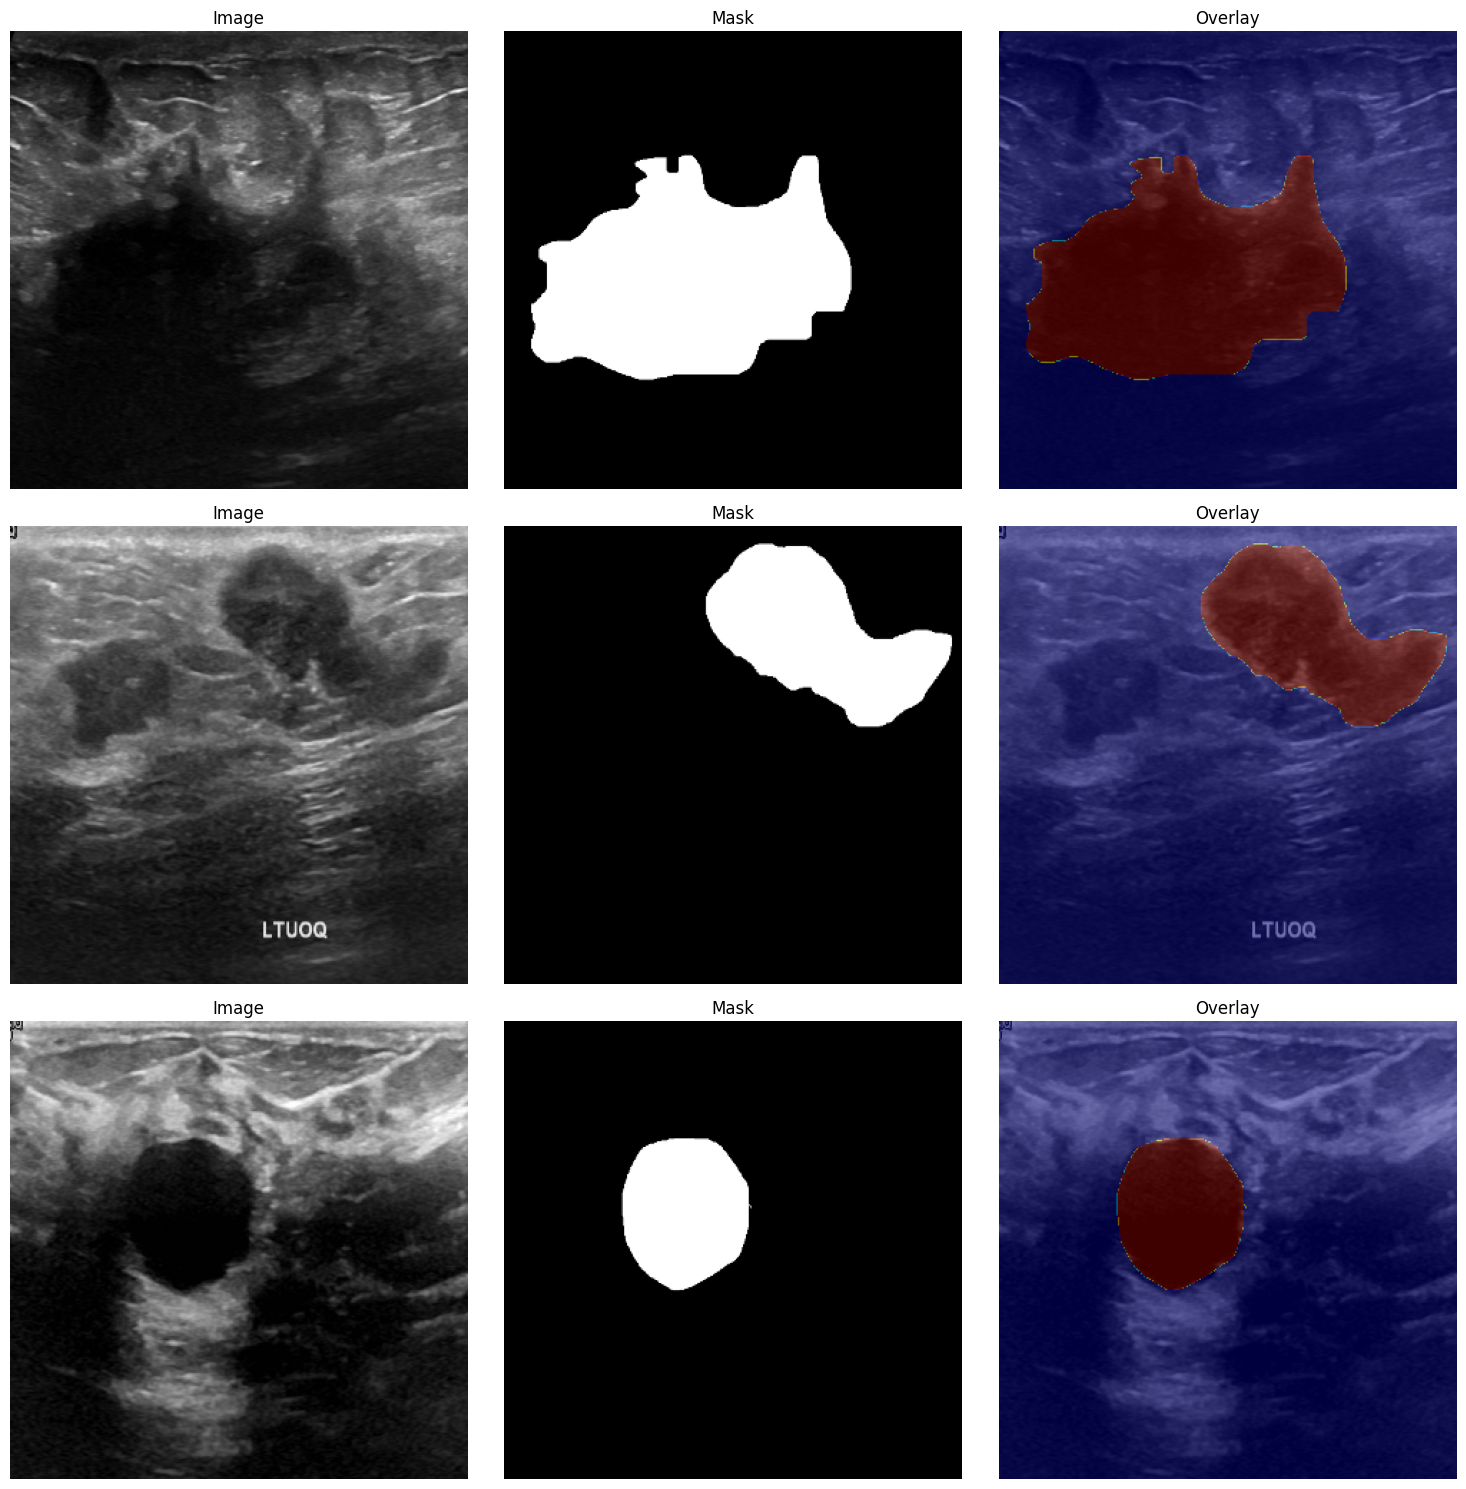

In [19]:
# Add channel dimension
y = np.expand_dims(y, -1)

# Visualize samples
def visualize_samples(images, masks, n_samples=3):
    fig, ax = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    indices = np.random.choice(len(images), n_samples)

    for i, idx in enumerate(indices):
        ax[i,0].imshow(images[idx])
        ax[i,0].set_title('Image')
        ax[i,0].axis('off')

        ax[i,1].imshow(masks[idx].squeeze(), cmap='gray')
        ax[i,1].set_title('Mask')
        ax[i,1].axis('off')

        ax[i,2].imshow(images[idx])
        ax[i,2].imshow(masks[idx].squeeze(), cmap='jet', alpha=0.5)
        ax[i,2].set_title('Overlay')
        ax[i,2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(X, y)
# Remove normal class (no masks)
X = X[:647]
y = y[:647]

In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nX_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")


X_train shape: (517, 320, 320, 3) | y_train shape: (517, 320, 320, 1)
X_test shape: (130, 320, 320, 3) | y_test shape: (130, 320, 320, 1)


In [21]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt

# 1. Custom Layers and Blocks
class ShapeMatch(tf.keras.layers.Layer):
    def call(self, inputs):
        source, target = inputs
        target_shape = tf.shape(target)[1:3]
        return tf.image.resize(source, target_shape)

def conv_block(inputs, filters, kernel_size=3, dilation_rate=1):
    x = Conv2D(filters, kernel_size, padding='same', dilation_rate=dilation_rate)(inputs)
    x = BatchNormalization()(x)
    return ReLU()(x)

def RSU_block(inputs, height, mid_channels, out_channels, dilated=False):
    # Down sampling
    conv1 = conv_block(inputs, out_channels)
    pool1 = MaxPooling2D(2, strides=2, padding='same')(conv1)

    conv2 = conv_block(pool1, mid_channels)
    pool2 = MaxPooling2D(2, strides=2, padding='same')(conv2)

    conv3 = conv_block(pool2, mid_channels)
    pool3 = MaxPooling2D(2, strides=2, padding='same')(conv3)

    conv4 = conv_block(pool3, mid_channels)
    pool4 = MaxPooling2D(2, strides=2, padding='same')(conv4)

    # Bridge
    conv5 = conv_block(pool4, mid_channels, dilation_rate=2 if dilated else 1)

    # Up sampling
    up4 = Conv2DTranspose(mid_channels, 2, strides=2, padding='same')(conv5)
    up4_matched = ShapeMatch()([up4, conv4])
    concat4 = concatenate([up4_matched, conv4])
    conv4_u = conv_block(concat4, mid_channels)

    up3 = Conv2DTranspose(mid_channels, 2, strides=2, padding='same')(conv4_u)
    up3_matched = ShapeMatch()([up3, conv3])
    concat3 = concatenate([up3_matched, conv3])
    conv3_u = conv_block(concat3, mid_channels)

    up2 = Conv2DTranspose(mid_channels, 2, strides=2, padding='same')(conv3_u)
    up2_matched = ShapeMatch()([up2, conv2])
    concat2 = concatenate([up2_matched, conv2])
    conv2_u = conv_block(concat2, out_channels)

    up1 = Conv2DTranspose(out_channels, 2, strides=2, padding='same')(conv2_u)
    up1_matched = ShapeMatch()([up1, conv1])
    concat1 = concatenate([up1_matched, conv1])
    conv1_u = conv_block(concat1, out_channels)

    return conv1_u

# 2. Model Architecture
def build_u2net(input_shape=(320, 320, 3)):
    inputs = Input(shape=input_shape)

    # Encoder
    s1 = RSU_block(inputs, height=7, mid_channels=32, out_channels=64)
    p1 = MaxPooling2D(2, strides=2, padding='same')(s1)

    s2 = RSU_block(p1, height=6, mid_channels=32, out_channels=128)
    p2 = MaxPooling2D(2, strides=2, padding='same')(s2)

    s3 = RSU_block(p2, height=5, mid_channels=64, out_channels=256)
    p3 = MaxPooling2D(2, strides=2, padding='same')(s3)

    s4 = RSU_block(p3, height=4, mid_channels=128, out_channels=512)
    p4 = MaxPooling2D(2, strides=2, padding='same')(s4)

    # Bridge
    s5 = RSU_block(p4, height=4, mid_channels=256, out_channels=512, dilated=True)

    # Decoder
    u1 = Conv2DTranspose(256, 2, strides=2, padding='same')(s5)
    u1_matched = ShapeMatch()([u1, s4])
    c1 = concatenate([u1_matched, s4])
    s6 = RSU_block(c1, height=4, mid_channels=128, out_channels=256)

    u2 = Conv2DTranspose(128, 2, strides=2, padding='same')(s6)
    u2_matched = ShapeMatch()([u2, s3])
    c2 = concatenate([u2_matched, s3])
    s7 = RSU_block(c2, height=5, mid_channels=64, out_channels=128)

    u3 = Conv2DTranspose(64, 2, strides=2, padding='same')(s7)
    u3_matched = ShapeMatch()([u3, s2])
    c3 = concatenate([u3_matched, s2])
    s8 = RSU_block(c3, height=6, mid_channels=32, out_channels=64)

    u4 = Conv2DTranspose(32, 2, strides=2, padding='same')(s8)
    u4_matched = ShapeMatch()([u4, s1])
    c4 = concatenate([u4_matched, s1])
    s9 = RSU_block(c4, height=7, mid_channels=16, out_channels=64)

    # Output
    outputs = Conv2D(1, 1, activation='sigmoid')(s9)

    return Model(inputs=inputs, outputs=outputs, name='U2Net')

# 3. Custom Metrics
class DiceScore(tf.keras.metrics.Metric):
    def __init__(self, name='dice_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.intersection = self.add_weight(name='intersection', initializer='zeros')
        self.union = self.add_weight(name='union', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred)
        union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
        self.intersection.assign_add(intersection)
        self.union.assign_add(union)

    def result(self):
        return (2. * self.intersection) / (self.union + 1e-7)

    def reset_states(self):
        self.intersection.assign(0.)
        self.union.assign(0.)

# 4. Data Preparation (Replace with your data)
# X_train, y_train = ... # Your training data
# X_val, y_val = ...     # Your validation data

# 5. Data Augmentation
def augment_data(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, mask

# 6. Training Configuration
BATCH_SIZE = 8
EPOCHS = 100

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (train_dataset
                .map(augment_data)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 7. Build and Compile Model
model = build_u2net(input_shape=(320, 320, 3))
model.compile(optimizer=Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', DiceScore()])

# 8. Callbacks
callbacks = [
    ModelCheckpoint('best_u2net.h5',
                  monitor='val_dice_score',
                  mode='max',
                  save_best_only=True,
                  verbose=1),
    EarlyStopping(monitor='val_dice_score',
                patience=15,
                mode='max',
                restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss',
                     factor=0.2,
                     patience=5,
                     min_lr=1e-6)
]

# 9. Training
history = model.fit(train_dataset,
                   validation_data=val_dataset,
                   epochs=EPOCHS,
                   callbacks=callbacks)

# 10. Evaluation
def evaluate_model(model, X_test, y_test):
    results = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)
    metrics = {
        'loss': results[0],
        'accuracy': results[1],
        'dice_score': results[2]
    }


NameError: name 'X_val' is not defined

In [22]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

class ShapeMatch(Layer):
    """Custom layer to handle shape matching between tensors"""
    def call(self, inputs):
        source, target = inputs
        target_shape = tf.shape(target)[1:3]  # Get H, W of target
        return tf.image.resize(source, target_shape)

def conv_block(inputs, filters, kernel_size=3, dilation_rate=1):
    """Basic convolutional block with BN and ReLU"""
    x = Conv2D(filters, kernel_size, padding='same', dilation_rate=dilation_rate)(inputs)
    x = BatchNormalization()(x)
    return ReLU()(x)

def RSU_block(inputs, height, mid_channels, out_channels, dilated=False):
    """Residual U-block (RSU) - Core building block"""
    # Down sampling
    conv1 = conv_block(inputs, out_channels)
    pool1 = MaxPooling2D(2, strides=2, padding='same')(conv1)

    conv2 = conv_block(pool1, mid_channels)
    pool2 = MaxPooling2D(2, strides=2, padding='same')(conv2)

    conv3 = conv_block(pool2, mid_channels)
    pool3 = MaxPooling2D(2, strides=2, padding='same')(conv3)

    conv4 = conv_block(pool3, mid_channels)
    pool4 = MaxPooling2D(2, strides=2, padding='same')(conv4)

    # Bridge with optional dilation
    conv5 = conv_block(pool4, mid_channels, dilation_rate=2 if dilated else 1)

    # Up sampling with shape matching
    up4 = Conv2DTranspose(mid_channels, 2, strides=2, padding='same')(conv5)
    up4_matched = ShapeMatch()([up4, conv4])
    concat4 = concatenate([up4_matched, conv4])
    conv4_u = conv_block(concat4, mid_channels)

    up3 = Conv2DTranspose(mid_channels, 2, strides=2, padding='same')(conv4_u)
    up3_matched = ShapeMatch()([up3, conv3])
    concat3 = concatenate([up3_matched, conv3])
    conv3_u = conv_block(concat3, mid_channels)

    up2 = Conv2DTranspose(mid_channels, 2, strides=2, padding='same')(conv3_u)
    up2_matched = ShapeMatch()([up2, conv2])
    concat2 = concatenate([up2_matched, conv2])
    conv2_u = conv_block(concat2, out_channels)

    up1 = Conv2DTranspose(out_channels, 2, strides=2, padding='same')(conv2_u)
    up1_matched = ShapeMatch()([up1, conv1])
    concat1 = concatenate([up1_matched, conv1])
    conv1_u = conv_block(concat1, out_channels)

    return conv1_u

def build_u2net(input_shape=(320, 320, 3)):
    """Complete U²-Net implementation"""
    inputs = Input(shape=input_shape)

    # ------------- Encoder -------------
    # Stage 1 (320x320)
    s1 = RSU_block(inputs, height=7, mid_channels=32, out_channels=64)
    p1 = MaxPooling2D(2, strides=2, padding='same')(s1)  # 160x160

    # Stage 2 (160x160)
    s2 = RSU_block(p1, height=6, mid_channels=32, out_channels=128)
    p2 = MaxPooling2D(2, strides=2, padding='same')(s2)  # 80x80

    # Stage 3 (80x80)
    s3 = RSU_block(p2, height=5, mid_channels=64, out_channels=256)
    p3 = MaxPooling2D(2, strides=2, padding='same')(s3)  # 40x40

    # Stage 4 (40x40)
    s4 = RSU_block(p3, height=4, mid_channels=128, out_channels=512)
    p4 = MaxPooling2D(2, strides=2, padding='same')(s4)  # 20x20

    # Stage 5 - Bridge (20x20 with dilated conv)
    s5 = RSU_block(p4, height=4, mid_channels=256, out_channels=512, dilated=True)

    # ------------- Decoder -------------
    # Stage 6 (40x40)
    u1 = Conv2DTranspose(256, 2, strides=2, padding='same')(s5)
    u1_matched = ShapeMatch()([u1, s4])
    c1 = concatenate([u1_matched, s4])
    s6 = RSU_block(c1, height=4, mid_channels=128, out_channels=256)

    # Stage 7 (80x80)
    u2 = Conv2DTranspose(128, 2, strides=2, padding='same')(s6)
    u2_matched = ShapeMatch()([u2, s3])
    c2 = concatenate([u2_matched, s3])
    s7 = RSU_block(c2, height=5, mid_channels=64, out_channels=128)

    # Stage 8 (160x160)
    u3 = Conv2DTranspose(64, 2, strides=2, padding='same')(s7)
    u3_matched = ShapeMatch()([u3, s2])
    c3 = concatenate([u3_matched, s2])
    s8 = RSU_block(c3, height=6, mid_channels=32, out_channels=64)

    # Stage 9 (320x320)
    u4 = Conv2DTranspose(32, 2, strides=2, padding='same')(s8)
    u4_matched = ShapeMatch()([u4, s1])
    c4 = concatenate([u4_matched, s1])
    s9 = RSU_block(c4, height=7, mid_channels=16, out_channels=64)

    # ------------- Output -------------
    outputs = Conv2D(1, 1, activation='sigmoid')(s9)

    return Model(inputs=inputs, outputs=outputs, name='U2Net')

# Build and compile model
model = build_u2net(input_shape=(320, 320, 3))
model.compile(optimizer=Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "U2Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 320, 320, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_178 (Conv2D)       │ (None, 320, 320, 64)   │          1,792 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_177   │ (None, 320, 320, 64)   │            256 │ conv2d_178[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_177 (ReLU)          │ (None, 320, 320, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_97          │ (None, 160, 160, 64)   │              0 │ re_lu_177[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_179 (Conv2D)       │ (None, 160, 160, 32)   │         18,464 │ max_pooling2d_97[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_178   │ (None, 160, 160, 32)   │            128 │ conv2d_179[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_178 (ReLU)          │ (None, 160, 160, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_98          │ (None, 80, 80, 32)     │              0 │ re_lu_178[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_180 (Conv2D)       │ (None, 80, 80, 32)     │          9,248 │ max_pooling2d_98[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_179   │ (None, 80, 80, 32)     │            128 │ conv2d_180[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_179 (ReLU)          │ (None, 80, 80, 32)     │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_99          │ (None, 40, 40, 32)     │              0 │ re_lu_179[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_181 (Conv2D)       │ (None, 40, 40, 32)     │          9,248 │ max_pooling2d_99[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_180   │ (None, 40, 40, 32)     │            128 │ conv2d_181[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_180 (ReLU)     

 Total params: 37,791,953 (144.16 MB)

 Trainable params: 37,771,025 (144.09 MB)

 Non-trainable params: 20,928 (81.75 KB)

In [1]:
history = model.fit(X_train, y_train, epochs = 25, validation_data = (X_test,y_test))

NameError: name 'model' is not defined